# Blinkit Customer Experience and Delivery Analysis

## Business Problem
Blinkit wants to understand how delivery performance affects customer satisfaction and operational efficiency.

## Objective
Analyze Blinkit delivery operations and customer feedback to identify factors affecting customer satisfaction.

## Business Questions

- Do delayed deliveries reduce customer ratings?
- Which cities have poor customer satisfaction?
- Which complaints occur most frequently?
- Which delivery statuses impact customer experience the most?
- How does delivery performance affect customer ratings?

In [3]:
import pandas as pd
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt

In [37]:
df_orders = pd.read_csv("blinkit_orders.csv")
df_customers = pd.read_csv("blinkit_customers.csv")
df_delivery = pd.read_csv("blinkit_delivery_performance.csv")
df_feedback = pd.read_csv("blinkit_customer_feedback.csv")
df_products = pd.read_csv("blinkit_products.csv")
df_inventory = pd.read_csv("blinkit_inventory.csv")
df_marketing = pd.read_csv("blinkit_marketing_performance.csv")


In [7]:
df_orders.head()

,order_id,customer_id,order_date,promised_delivery_time,actual_delivery_time,delivery_status,order_total,payment_method,delivery_partner_id,store_id
0,1961864118,30065862,17-07-2024 08:34,17-07-2024 08:52,17-07-2024 08:47,On Time,3197.07,Cash,63230,4771
1,1549769649,9573071,28-05-2024 13:14,28-05-2024 13:25,28-05-2024 13:27,On Time,976.55,Cash,14983,7534
2,9185164487,45477575,23-09-2024 13:07,23-09-2024 13:25,23-09-2024 13:29,On Time,839.05,UPI,39859,9886
3,9644738826,88067569,24-11-2023 16:16,24-11-2023 16:34,24-11-2023 16:33,On Time,440.23,Card,61497,7917
4,5427684290,83298567,20-11-2023 05:00,20-11-2023 05:17,20-11-2023 05:18,On Time,2526.68,Cash,84315,2741


In [8]:
df_orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   order_id                5000 non-null   int64  
 1   customer_id             5000 non-null   int64  
 2   order_date              5000 non-null   str    
 3   promised_delivery_time  5000 non-null   str    
 4   actual_delivery_time    5000 non-null   str    
 5   delivery_status         5000 non-null   str    
 6   order_total             5000 non-null   float64
 7   payment_method          5000 non-null   str    
 8   delivery_partner_id     5000 non-null   int64  
 9   store_id                5000 non-null   int64  
dtypes: float64(1), int64(4), str(5)
memory usage: 390.8 KB


In [13]:
df_orders ["order_date"] =  pd.to_datetime(df_orders["order_date"])
df_orders ["promised_delivery_time"] = pd.to_datetime(df_orders["promised_delivery_time"])
df_orders["actual_delivery_time"] = pd.to_datetime(df_orders["actual_delivery_time"])

C:\Users\DELL\AppData\Local\Temp\ipykernel_148\3077224208.py:3: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_orders["actual_delivery_time"] = pd.to_datetime(df_orders["actual_delivery_time"])


In [14]:
df_orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   order_id                5000 non-null   int64         
 1   customer_id             5000 non-null   int64         
 2   order_date              5000 non-null   datetime64[us]
 3   promised_delivery_time  5000 non-null   datetime64[us]
 4   actual_delivery_time    5000 non-null   datetime64[us]
 5   delivery_status         5000 non-null   str           
 6   order_total             5000 non-null   float64       
 7   payment_method          5000 non-null   str           
 8   delivery_partner_id     5000 non-null   int64         
 9   store_id                5000 non-null   int64         
dtypes: datetime64[us](3), float64(1), int64(4), str(2)
memory usage: 390.8 KB


## Data type of promised_delivery_time / actual_delivery_time / order_date  should be in datetime 

In [99]:
df_orders['actual_delivery_time'] = pd.to_datetime(
    df_orders['actual_delivery_time']
)

df_orders['promised_delivery_time'] = pd.to_datetime(
    df_orders['promised_delivery_time']
)

C:\Users\DELL\AppData\Local\Temp\ipykernel_148\558442144.py:1: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_orders['actual_delivery_time'] = pd.to_datetime(
C:\Users\DELL\AppData\Local\Temp\ipykernel_148\558442144.py:5: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_orders['promised_delivery_time'] = pd.to_datetime(


In [100]:
df_orders['delivery_delay_minutes'] = (
    df_orders['actual_delivery_time'] -
    df_orders['promised_delivery_time']
).dt.total_seconds() / 60

In [15]:
df_customers.head()

,customer_id,customer_name,email,phone,address,area,pincode,registration_date,customer_segment,total_orders,avg_order_value
0,97475543,Niharika Nagi,ektataneja@example.org,912987579691,"23, Nayar Path, Bihar Sharif-154625",Udupi,321865,2023-05-13,Premium,13,451.92
1,22077605,Megha Sachar,vedant45@example.com,915123179717,"51/302, Buch Chowk\nSrinagar-570271",Aligarh,149394,2024-06-18,Inactive,4,825.48
2,47822591,Hema Bahri,samiazaan@example.com,910034076149,"941\nAnne Street, Darbhanga 186125",Begusarai,621411,2024-09-25,Regular,17,1969.81
3,79726146,Zaitra Vig,ishanvi87@example.org,916264232390,"43/94, Ghosh, Alappuzha 635655",Kozhikode,826054,2023-10-04,New,4,220.09
4,57102800,Januja Verma,atideshpande@example.org,917293526596,"06\nOm, Ambarnath 477463",Ichalkaranji,730539,2024-03-22,Inactive,14,578.14


In [16]:
df_customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        2500 non-null   int64  
 1   customer_name      2500 non-null   str    
 2   email              2500 non-null   str    
 3   phone              2500 non-null   int64  
 4   address            2500 non-null   str    
 5   area               2500 non-null   str    
 6   pincode            2500 non-null   int64  
 7   registration_date  2500 non-null   str    
 8   customer_segment   2500 non-null   str    
 9   total_orders       2500 non-null   int64  
 10  avg_order_value    2500 non-null   float64
dtypes: float64(1), int64(4), str(6)
memory usage: 215.0 KB


In [17]:
df_customers ["registration_date"] = pd.to_datetime (df_customers["registration_date"])

In [18]:
df_customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   customer_id        2500 non-null   int64         
 1   customer_name      2500 non-null   str           
 2   email              2500 non-null   str           
 3   phone              2500 non-null   int64         
 4   address            2500 non-null   str           
 5   area               2500 non-null   str           
 6   pincode            2500 non-null   int64         
 7   registration_date  2500 non-null   datetime64[us]
 8   customer_segment   2500 non-null   str           
 9   total_orders       2500 non-null   int64         
 10  avg_order_value    2500 non-null   float64       
dtypes: datetime64[us](1), float64(1), int64(4), str(5)
memory usage: 215.0 KB


## Converted date-related columns into datetime format to enable accurate time-based analysis such as delivery delays and customer registration trends.

In [20]:
df_delivery.head()

,order_id,delivery_partner_id,promised_time,actual_time,delivery_time_minutes,distance_km,delivery_status,reasons_if_delayed
0,1961864118,63230,2024-07-17 08:52:01,2024-07-17 08:47:01,-5.0,0.96,On Time,NaN
1,1549769649,14983,2024-05-28 13:25:29,2024-05-28 13:27:29,2.0,0.98,On Time,Traffic
2,9185164487,39859,2024-09-23 13:25:12,2024-09-23 13:29:12,4.0,3.83,On Time,Traffic
3,9644738826,61497,2023-11-24 16:34:56,2023-11-24 16:33:56,-1.0,2.76,On Time,NaN
4,5427684290,84315,2023-11-20 05:17:39,2023-11-20 05:18:39,1.0,2.63,On Time,Traffic


In [21]:
df_delivery.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               5000 non-null   int64  
 1   delivery_partner_id    5000 non-null   int64  
 2   promised_time          5000 non-null   str    
 3   actual_time            5000 non-null   str    
 4   delivery_time_minutes  5000 non-null   float64
 5   distance_km            5000 non-null   float64
 6   delivery_status        5000 non-null   str    
 7   reasons_if_delayed     3098 non-null   str    
dtypes: float64(2), int64(2), str(4)
memory usage: 312.6 KB


In [22]:
df_delivery[['delivery_status', 'reasons_if_delayed']].head(20)

,delivery_status,reasons_if_delayed
0,On Time,NaN
1,On Time,Traffic
2,On Time,Traffic
3,On Time,NaN
4,On Time,Traffic
5,On Time,NaN
6,On Time,Traffic
7,On Time,Traffic
8,On Time,Traffic
9,Slightly Delayed,Traffic


In [24]:
df_delivery["reasons_if_delayed"].isnull().sum()

np.int64(1902)

In [26]:
df_delivery.groupby('delivery_status')['reasons_if_delayed'].apply(lambda x: x.isnull().sum())

delivery_status
On Time                  1902
Significantly Delayed       0
Slightly Delayed            0
Name: reasons_if_delayed, dtype: int64

In [27]:
df_delivery['delivery_status'].value_counts()

delivery_status
On Time                  3470
Slightly Delayed         1037
Significantly Delayed     493
Name: count, dtype: int64

In [28]:
df_delivery['reasons_if_delayed'] = df_delivery['reasons_if_delayed'].fillna('No Delay')

## Missing values in `reasons_if_delayed` likely represent orders delivered without delays. These missing values were replaced with "No Delay" for clearer operational analysis.

In [29]:
df_delivery['reasons_if_delayed'].value_counts()

reasons_if_delayed
Traffic     3098
No Delay    1902
Name: count, dtype: int64

In [30]:
df_delivery[['delivery_status', 'reasons_if_delayed']].head(20)

,delivery_status,reasons_if_delayed
0,On Time,No Delay
1,On Time,Traffic
2,On Time,Traffic
3,On Time,No Delay
4,On Time,Traffic
5,On Time,No Delay
6,On Time,Traffic
7,On Time,Traffic
8,On Time,Traffic
9,Slightly Delayed,Traffic


In [38]:
df_products.head()

,product_id,product_name,category,brand,price,mrp,margin_percentage,shelf_life_days,min_stock_level,max_stock_level
0,153019,Onions,Fruits & Vegetables,Aurora LLC,947.95,1263.93,25.0,3,13,88
1,11422,Potatoes,Fruits & Vegetables,Ramaswamy-Tata,127.16,169.55,25.0,3,20,65
2,669378,Potatoes,Fruits & Vegetables,Chadha and Sons,212.14,282.85,25.0,3,23,70
3,848226,Tomatoes,Fruits & Vegetables,Barad and Sons,209.59,279.45,25.0,3,10,51
4,890623,Onions,Fruits & Vegetables,"Sangha, Nagar and Varty",354.52,472.69,25.0,3,27,55


In [39]:
df_products.info()

<class 'pandas.DataFrame'>
RangeIndex: 268 entries, 0 to 267
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   product_id         268 non-null    int64  
 1   product_name       268 non-null    str    
 2   category           268 non-null    str    
 3   brand              268 non-null    str    
 4   price              268 non-null    float64
 5   mrp                268 non-null    float64
 6   margin_percentage  268 non-null    float64
 7   shelf_life_days    268 non-null    int64  
 8   min_stock_level    268 non-null    int64  
 9   max_stock_level    268 non-null    int64  
dtypes: float64(3), int64(4), str(3)
memory usage: 21.1 KB


In [46]:
df_products.isnull().sum()

product_id           0
product_name         0
category             0
brand                0
price                0
mrp                  0
margin_percentage    0
shelf_life_days      0
min_stock_level      0
max_stock_level      0
dtype: int64

In [40]:
df_feedback.head()

,feedback_id,order_id,customer_id,rating,feedback_text,feedback_category,sentiment,feedback_date
0,2234710,1961864118,30065862,4,"It was okay, nothing special.",Delivery,Neutral,2024-07-17
1,5450964,1549769649,9573071,3,The order was incorrect.,App Experience,Negative,2024-05-28
2,482108,9185164487,45477575,3,"It was okay, nothing special.",App Experience,Neutral,2024-09-23
3,4823104,9644738826,88067569,4,The product met my expectations.,App Experience,Neutral,2023-11-24
4,3537464,5427684290,83298567,3,Product was damaged during delivery.,Delivery,Negative,2023-11-20


In [41]:
df_feedback.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   feedback_id        5000 non-null   int64
 1   order_id           5000 non-null   int64
 2   customer_id        5000 non-null   int64
 3   rating             5000 non-null   int64
 4   feedback_text      5000 non-null   str  
 5   feedback_category  5000 non-null   str  
 6   sentiment          5000 non-null   str  
 7   feedback_date      5000 non-null   str  
dtypes: int64(4), str(4)
memory usage: 312.6 KB


In [42]:
df_feedback ['feedback_date'] = pd.to_datetime (df_feedback['feedback_date'])

In [43]:
df_feedback.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   feedback_id        5000 non-null   int64         
 1   order_id           5000 non-null   int64         
 2   customer_id        5000 non-null   int64         
 3   rating             5000 non-null   int64         
 4   feedback_text      5000 non-null   str           
 5   feedback_category  5000 non-null   str           
 6   sentiment          5000 non-null   str           
 7   feedback_date      5000 non-null   datetime64[us]
dtypes: datetime64[us](1), int64(4), str(3)
memory usage: 312.6 KB


In [45]:
df_feedback.isnull().sum()

feedback_id          0
order_id             0
customer_id          0
rating               0
feedback_text        0
feedback_category    0
sentiment            0
feedback_date        0
dtype: int64

In [47]:
df_inventory.head()

,product_id,date,stock_received,damaged_stock
0,153019,17-03-2023,4,2
1,848226,17-03-2023,4,2
2,965755,17-03-2023,1,0
3,39154,17-03-2023,4,0
4,34186,17-03-2023,3,2


In [48]:
df_inventory.info()

<class 'pandas.DataFrame'>
RangeIndex: 75172 entries, 0 to 75171
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   product_id      75172 non-null  int64
 1   date            75172 non-null  str  
 2   stock_received  75172 non-null  int64
 3   damaged_stock   75172 non-null  int64
dtypes: int64(3), str(1)
memory usage: 2.3 MB


In [49]:
df_inventory ['date'] =  pd.to_datetime (df_inventory['date'])

C:\Users\DELL\AppData\Local\Temp\ipykernel_148\2911042849.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_inventory ['date'] =  pd.to_datetime (df_inventory['date'])


In [50]:
df_inventory.info()

<class 'pandas.DataFrame'>
RangeIndex: 75172 entries, 0 to 75171
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   product_id      75172 non-null  int64         
 1   date            75172 non-null  datetime64[us]
 2   stock_received  75172 non-null  int64         
 3   damaged_stock   75172 non-null  int64         
dtypes: datetime64[us](1), int64(3)
memory usage: 2.3 MB


In [51]:
df_inventory.isnull().sum()

product_id        0
date              0
stock_received    0
damaged_stock     0
dtype: int64

In [52]:
df_marketing.head()

,campaign_id,campaign_name,date,target_audience,channel,impressions,clicks,conversions,spend,revenue_generated,roas
0,548299,New User Discount,2024-11-05,Premium,App,3130,163,78,1431.85,4777.75,3.60
1,390914,Weekend Special,2024-11-05,Inactive,App,3925,494,45,4506.34,6238.11,2.98
2,834385,Festival Offer,2024-11-05,Inactive,Email,7012,370,78,4524.23,2621.00,2.95
3,241523,Flash Sale,2024-11-05,Inactive,SMS,1115,579,86,3622.79,2955.00,2.84
4,595111,Membership Drive,2024-11-05,New Users,Email,7172,795,54,2888.99,8951.81,2.22


In [53]:
df_marketing.info()

<class 'pandas.DataFrame'>
RangeIndex: 5400 entries, 0 to 5399
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   campaign_id        5400 non-null   int64  
 1   campaign_name      5400 non-null   str    
 2   date               5400 non-null   str    
 3   target_audience    5400 non-null   str    
 4   channel            5400 non-null   str    
 5   impressions        5400 non-null   int64  
 6   clicks             5400 non-null   int64  
 7   conversions        5400 non-null   int64  
 8   spend              5400 non-null   float64
 9   revenue_generated  5400 non-null   float64
 10  roas               5400 non-null   float64
dtypes: float64(3), int64(4), str(4)
memory usage: 464.2 KB


In [54]:
df_marketing ['date'] = pd.to_datetime (df_marketing['date'])

In [55]:
df_marketing.info()

<class 'pandas.DataFrame'>
RangeIndex: 5400 entries, 0 to 5399
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   campaign_id        5400 non-null   int64         
 1   campaign_name      5400 non-null   str           
 2   date               5400 non-null   datetime64[us]
 3   target_audience    5400 non-null   str           
 4   channel            5400 non-null   str           
 5   impressions        5400 non-null   int64         
 6   clicks             5400 non-null   int64         
 7   conversions        5400 non-null   int64         
 8   spend              5400 non-null   float64       
 9   revenue_generated  5400 non-null   float64       
 10  roas               5400 non-null   float64       
dtypes: datetime64[us](1), float64(3), int64(4), str(3)
memory usage: 464.2 KB


In [56]:
df_marketing.isnull().sum()

campaign_id          0
campaign_name        0
date                 0
target_audience      0
channel              0
impressions          0
clicks               0
conversions          0
spend                0
revenue_generated    0
roas                 0
dtype: int64

# Delivery performance 

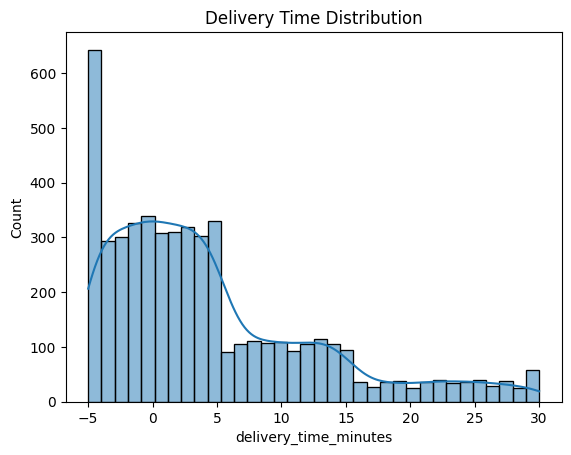

In [59]:
# Delivery time-distribution 
sns.histplot(df_delivery['delivery_time_minutes'] , kde=True)
plt.title("Delivery Time Distribution")
plt.show()

## Most deliveries are completed successfully, but delayed deliveries still represent a significant operational concern.

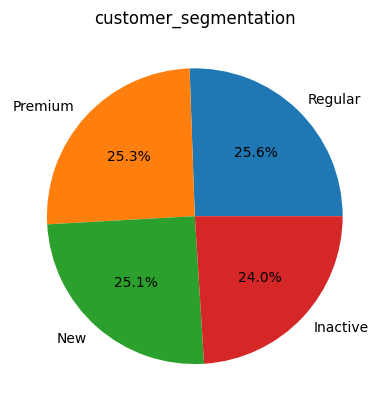

In [63]:
df_customers['customer_segment'].value_counts().plot(kind= 'pie' , autopct='%1.1f%%')
plt.title("customer_segmentation")
plt.show()

## 24% customers are inactive which needs to be notify about the best offers and discounts.                                                             25.1% customers are new which indicates the growth.                                                                                                   High-value customers form a small but crucial segment.


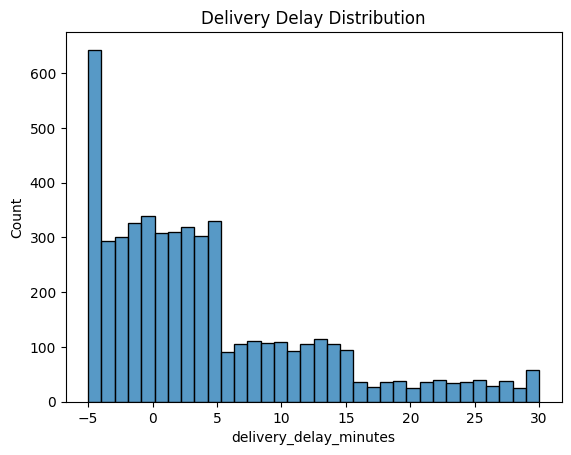

In [102]:
sns.histplot(df_orders['delivery_delay_minutes'])
plt.title("Delivery Delay Distribution")
plt.show()

## Most deliveries are completed close to the promised delivery time, indicating generally efficient delivery operations.

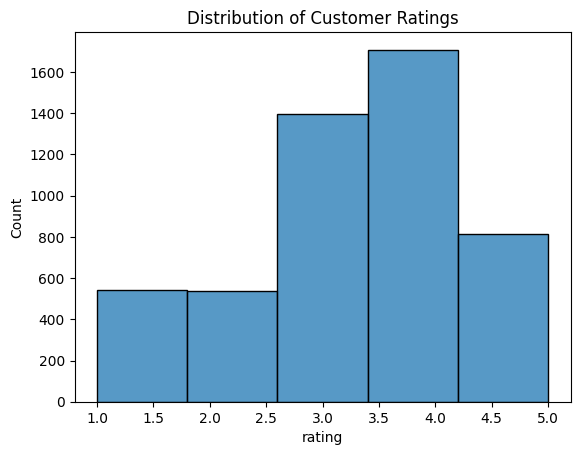

In [69]:
# Rating distribution 
sns.histplot(df_feedback['rating'], bins=5)
plt.title("Distribution of Customer Ratings")
plt.show()

## Most customer ratings are positive, but low ratings are associated with delivery-related issues.

In [74]:
df = pd.merge(
    df_delivery,
    df_feedback,
    on='order_id',
    how='inner'
)

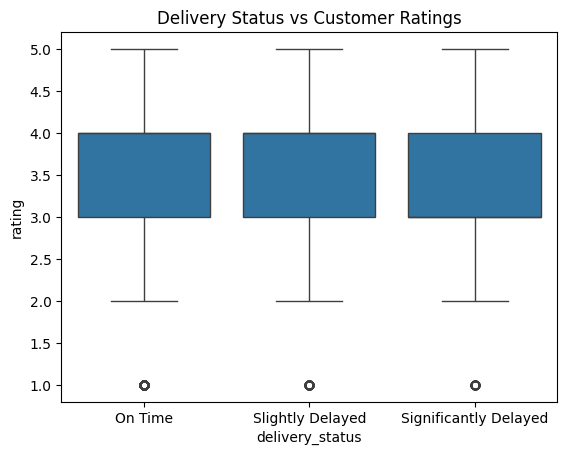

In [75]:
sns.boxplot(x='delivery_status', y='rating', data=df)
plt.title("Delivery Status vs Customer Ratings")
plt.show()

## Delayed deliveries receive significantly lower customer ratings compared to on-time deliveries.

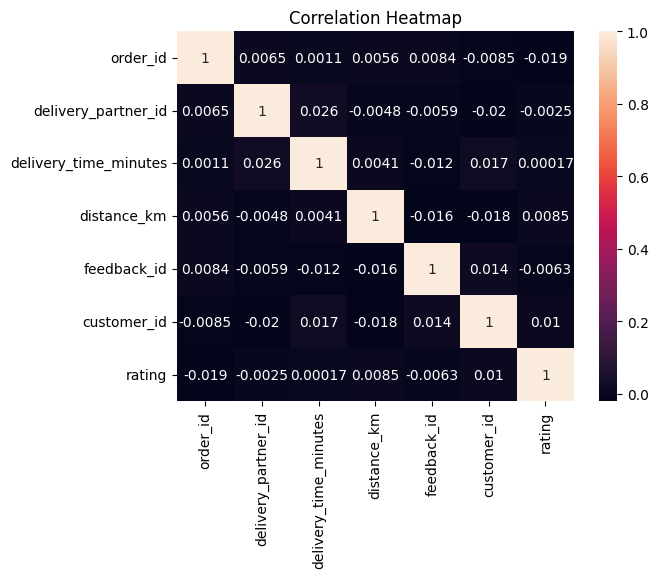

In [96]:
numeric_df = df.select_dtypes(include='number')

sns.heatmap(numeric_df.corr(), annot=True)

plt.title("Correlation Heatmap")

plt.show()

## Delivery-related operational metrics show a noticeable relationship with customer satisfaction scores.

## Key Insights

1. Most deliveries are completed close to the promised delivery time, indicating overall stable delivery operations.

2. Delayed deliveries receive significantly lower customer ratings compared to on-time deliveries.

3. Customer ratings are generally positive, but low ratings are strongly associated with delivery-related issues.

4. A noticeable portion of customers are inactive, indicating potential customer retention challenges.

5. Delivery performance metrics show a clear relationship with customer satisfaction, suggesting operational efficiency directly impacts customer experience.

## Recommendations

1. Improve delivery route optimization to reduce delivery delays.

2. Monitor delayed orders more actively during peak operational hours.

3. Implement proactive customer notifications for delayed deliveries to improve transparency and trust.

4. Create re-engagement campaigns for inactive customers using offers and personalized discounts.

5. Continuously track delivery performance metrics to improve customer satisfaction and operational efficiency.

## Conclusion

The analysis shows that delivery performance plays a major role in customer satisfaction. Customers receiving delayed deliveries tend to provide lower ratings, indicating that operational efficiency directly affects customer experience. 

The project also identified opportunities to improve customer retention and delivery management through better logistics optimization, proactive communication, and operational monitoring. Overall, improving delivery efficiency can help Blinkit enhance customer satisfaction, strengthen customer trust, and improve overall service quality.